Data Science Job Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import dataset
df=pd.read_csv("salary_data_cleaned - salary_data_cleaned.csv")

📊 Part 1: Data Understanding & Quality (Beginner)

In [3]:
#How many rows and columns are in the dataset? What does each row represent?
df.shape

(742, 28)

In [4]:
#Identify all numeric and categorical columns. Are the data types appropriate for each column?
#Numeric columns
df.select_dtypes(include='number').columns


Index(['Rating', 'Founded', 'hourly', 'employer_provided', 'min_salary',
       'max_salary', 'avg_salary', 'same_state', 'age', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel'],
      dtype='str')

In [5]:
#Categorical columns
df.select_dtypes(exclude='number').columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Company Name',
       'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry',
       'Sector', 'Revenue', 'Competitors', 'company_txt', 'job_state'],
      dtype='str')

Check for missing values in each column. Are there any patterns in the missing data?

In [6]:
#Missing value
df.isnull().sum()

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
hourly               0
employer_provided    0
min_salary           0
max_salary           0
avg_salary           0
company_txt          0
job_state            0
same_state           0
age                  0
python_yn            0
R_yn                 0
spark                0
aws                  0
excel                0
dtype: int64

In [7]:
#Duplicated value
df.duplicated()
df.apply(lambda col: col.duplicated().sum())

Job Title            478
Salary Estimate      326
Job Description      279
Rating               711
Company Name         399
Location             542
Headquarters         544
Size                 733
Founded              640
Type of ownership    731
Industry             682
Sector               717
Revenue              728
Competitors          614
hourly               740
employer_provided    740
min_salary           623
max_salary           579
avg_salary           517
company_txt          399
job_state            704
same_state           740
age                  640
python_yn            740
R_yn                 740
spark                740
aws                  740
excel                740
dtype: int64

In [8]:
#Drop Duplicates
df.drop_duplicates()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,avg_salary,company_txt,job_state,same_state,age,python_yn,R_yn,spark,aws,excel
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,72.0,Tecolote Research\n,NM,0,47,1,0,0,0,1
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,87.5,University of Maryland Medical System\n,MD,0,36,1,0,0,0,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,85.0,KnowBe4\n,FL,1,10,1,0,1,0,1
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,76.5,PNNL\n,WA,1,55,1,0,0,0,0
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,114.5,Affinity Solutions\n,NY,1,22,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Data Architect / Data Modeler,$63K-$110K (Glassdoor est.),Medidata: Conquering Diseases Together\n\nMedi...,4.3,Medidata Solutions\n4.3,"New York, NY","New York, NY",1001 to 5000 employees,1999,Company - Public,...,86.5,Medidata Solutions\n,NY,1,21,0,0,0,1,1
700,Data Scientist,$65K-$113K (Glassdoor est.),DatamanUSA has an exciting opportunity for a D...,3.4,"DatamanUSA, LLC\n3.4","Olympia, WA","Centennial, CO",51 to 200 employees,-1,Company - Private,...,89.0,"DatamanUSA, LLC\n",WA,0,-1,0,0,0,0,0
716,"Associate Scientist / Sr. Associate Scientist,...",$59K-$125K (Glassdoor est.),"Who we are\n\n23andMe, the leading consumer ge...",4.0,23andMe\n4.0,"South San Francisco, CA","Sunnyvale, CA",501 to 1000 employees,2006,Company - Private,...,92.0,23andMe\n,CA,0,14,0,0,0,1,1
732,Machine Learning Engineer (NLP),$80K-$142K (Glassdoor est.),CK-12’s mission is to provide free access to o...,4.1,CK-12 Foundation\n4.1,"Palo Alto, CA","Palo Alto, CA",1 to 50 employees,2007,Company - Private,...,111.0,CK-12 Foundation\n,CA,1,13,1,0,0,1,1


Identify outliers in the salary columns (min_salary, max_salary, avg_salary). What defines an outlier in this context?


In [9]:
#Detecting outliers for Avg salary
Q1 = df['avg_salary'].quantile(0.25)
Q3 = df['avg_salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

0.0 196.0


In [10]:
df['avg_salary'].describe()

count    742.000000
mean     100.626011
std       38.855948
min       13.500000
25%       73.500000
50%       97.500000
75%      122.500000
max      254.000000
Name: avg_salary, dtype: float64

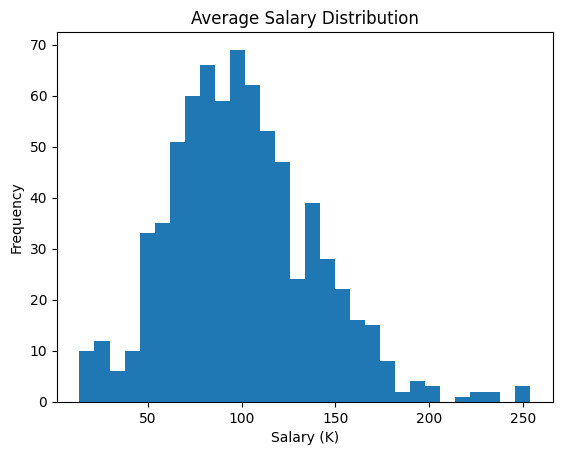

In [11]:
plt.hist(df['avg_salary'], bins=30)
plt.title("Average Salary Distribution")
plt.xlabel("Salary (K)")
plt.ylabel("Frequency")
plt.show()

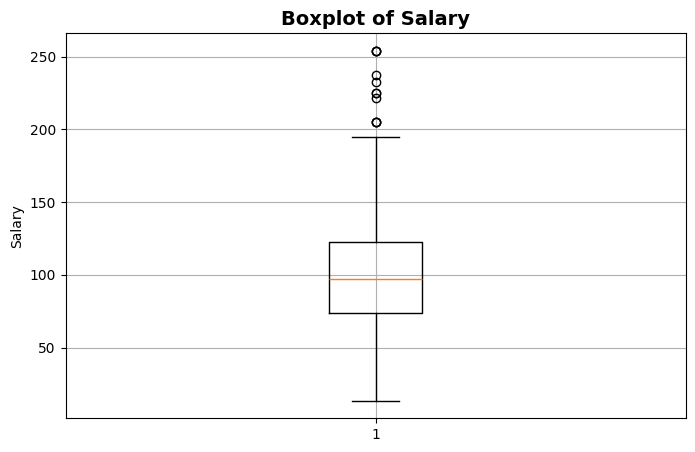

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df['avg_salary'])
plt.title('Boxplot of Salary', fontsize=14, fontweight='bold')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

Company Rating Distribution

In [13]:
df['Rating'].describe()

count    742.000000
mean       3.618868
std        0.801210
min       -1.000000
25%        3.300000
50%        3.700000
75%        4.000000
max        5.000000
Name: Rating, dtype: float64

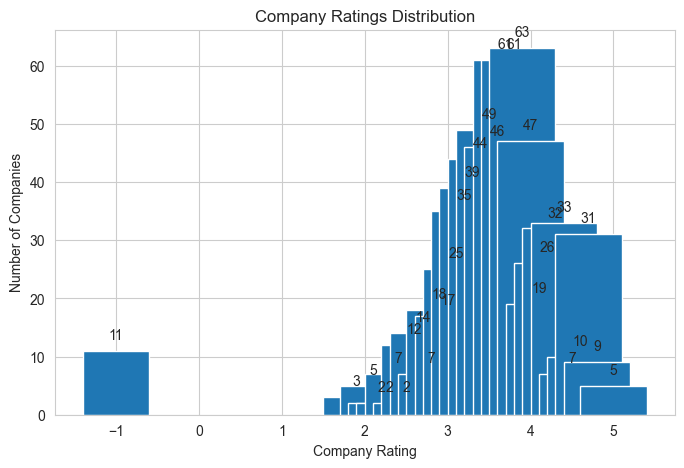

In [21]:
plt.figure(figsize=(8,5))

bars = plt.bar(rating_counts.index, rating_counts.values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, yval, ha='center')

plt.xlabel("Company Rating")
plt.ylabel("Number of Companies")
plt.title("Company Ratings Distribution")

plt.show()

Company Age

In [25]:
# Using drop()
df.drop(df[df['age'] == -1].index, inplace=True)
df['age'].describe()

count    692.000000
mean      50.030347
std       54.089762
min        1.000000
25%       13.000000
50%       28.000000
75%       62.000000
max      276.000000
Name: age, dtype: float64

Salary Comparison

In [26]:
df[['min_salary','max_salary','avg_salary']].describe()

,min_salary,max_salary,avg_salary
count,692.000000,692.000000,692.000000
mean,73.747110,127.238439,100.492775
std,32.139141,47.780729,39.488874
min,10.000000,16.000000,13.500000
25%,52.000000,96.000000,73.000000
50%,68.000000,124.000000,96.250000
75%,91.000000,157.000000,123.500000
max,202.000000,306.000000,254.000000


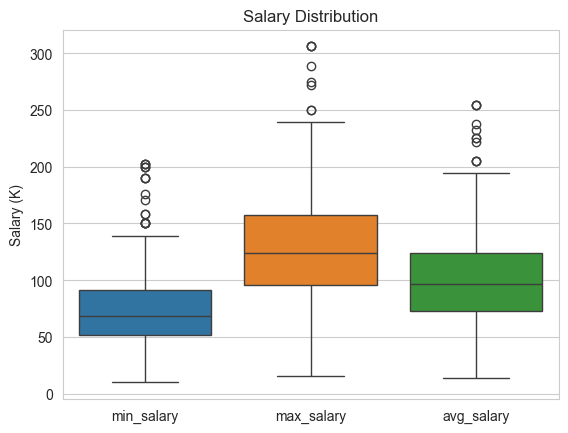

In [27]:
sns.boxplot(data=df[['min_salary','max_salary','avg_salary']])
plt.title("Salary Distribution")
plt.ylabel("Salary (K)")
plt.show()

🧾 Categorical Analysis

In [28]:
#Top 10 Job title
df['Job Title'].value_counts().head(10)

Job Title
Data Scientist               118
Data Engineer                 48
Senior Data Scientist         34
Data Analyst                  14
Senior Data Engineer          14
Senior Data Analyst           12
Lead Data Scientist            8
Marketing Data Analyst         6
Sr. Data Engineer              6
Machine Learning Engineer      5
Name: count, dtype: int64